In [ ]:
import urllib.request
import gzip
import os

def download_mnist_via_keras():
    try:
        import tensorflow as tf
        print("Using TensorFlow/Keras to download MNIST...")
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
        print("Converting Keras format to CSV...")
        print("Converting training data...")
        with open("mnist_train.csv", "w") as f:
            for i in range(len(x_train)):
                label = y_train[i]
                pixels = x_train[i].flatten()
                line = f"{label}," + ",".join(str(p) for p in pixels) + "\n"
                f.write(line)
                if (i + 1) % 10000 == 0:
                    print(f"  Processed {i + 1}/{len(x_train)} training samples")
        print("Converting test data...")
        with open("mnist_test.csv", "w") as f:
            for i in range(len(x_test)):
                label = y_test[i]
                pixels = x_test[i].flatten()
                line = f"{label}," + ",".join(str(p) for p in pixels) + "\n"
                f.write(line)
                if (i + 1) % 2000 == 0:
                    print(f"  Processed {i + 1}/{len(x_test)} test samples")

        print("Conversion complete using Keras method!")
        return True
    except ImportError:
        print("TensorFlow not available for Keras method")
        return False
    except Exception as e:
        print(f"Error with Keras method: {e}")
        return False

def download_and_extract_mnist():
    """Download and extract MNIST files if they don't exist"""
    files = [
        "train-images-idx3-ubyte.gz",
        "train-labels-idx1-ubyte.gz",
        "t10k-images-idx3-ubyte.gz",
        "t10k-labels-idx1-ubyte.gz"
    ]
    base_urls = [
        "https://ossci-datasets.s3.amazonaws.com/mnist/",
        "http://yann.lecun.com/exdb/mnist/",
        "https://github.com/cvdfoundation/mnist/raw/main/",
    ]

    for file in files:
        extracted_file = file[:-3]

        if not os.path.exists(extracted_file):
            print(f"Downloading {file}...")
            downloaded = False
            for base_url in base_urls:
                try:
                    print(f"  Trying {base_url}{file}")
                    urllib.request.urlretrieve(base_url + file, file)
                    downloaded = True
                    break
                except Exception as e:
                    print(f"  Failed: {e}")
                    continue
            if not downloaded:
                print(f"Could not download {file} from any source!")
                print("\nManual download instructions:")
                print("1. Go to http://yann.lecun.com/exdb/mnist/")
                print("2. Download these files manually:")
                print("   - train-images-idx3-ubyte.gz")
                print("   - train-labels-idx1-ubyte.gz")
                print("   - t10k-images-idx3-ubyte.gz")
                print("   - t10k-labels-idx1-ubyte.gz")
                print("3. Extract them using gunzip or any archive tool")
                print("4. Run the converter again")
                return False

            try:
                print(f"Extracting {file}...")
                with gzip.open(file, 'rb') as f_in:
                    with open(extracted_file, 'wb') as f_out:
                        f_out.write(f_in.read())
                os.remove(file)
                print(f"Successfully extracted {extracted_file}")

            except Exception as e:
                print(f"Error extracting {file}: {e}")
                return False
        else:
            print(f"{extracted_file} already exists, skipping download")

    return True

def convert(imgf, labelf, outf, n):
    try:
        f = open(imgf, "rb")
        o = open(outf, "w")
        l = open(labelf, "rb")
    except FileNotFoundError as e:
        print(f"Error: {e}")
        print("Make sure the MNIST files are downloaded first!")
        return False
    f.read(16)
    l.read(8)
    images = []

    print(f"Converting {n} samples from {imgf} and {labelf} to {outf}...")

    for i in range(n):
        image = [ord(l.read(1))]
        for j in range(28*28):
            image.append(ord(f.read(1)))
        images.append(image)
        if (i + 1) % 10000 == 0:
            print(f"Processed {i + 1}/{n} samples")
    for image in images:
        o.write(",".join(str(pix) for pix in image) + "\n")

    f.close()
    o.close()
    l.close()
    print(f"Conversion complete! Saved to {outf}")
    return True
print("Checking for MNIST files...")
success = False
if download_and_extract_mnist():
    print("\nStarting IDX to CSV conversion...")
    if convert("train-images-idx3-ubyte", "train-labels-idx1-ubyte",
               "mnist_train.csv", 60000):

        if convert("t10k-images-idx3-ubyte", "t10k-labels-idx1-ubyte",
                  "mnist_test.csv", 10000):
            success = True

if not success:
    print("\nAutomatic download failed. Trying alternative method...")
    if download_mnist_via_keras():
        success = True

if success:
    print("\nAll conversions completed successfully!")
    print("Files created:")
    print("- mnist_train.csv (60,000 samples)")
    print("- mnist_test.csv (10,000 samples)")
    print("\nYou can now use these files with your TensorFlow training script!")
else:
    print("\nBoth automatic methods failed.")
    print("\nManual download option:")
    print("1. Visit: https://www.kaggle.com/datasets/oddrationale/mnist-in-csv")
    print("2. Download 'mnist_train.csv' and 'mnist_test.csv'")
    print("3. Use them directly with your training script")

Checking for MNIST files...
  Trying https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz
Extracting train-images-idx3-ubyte.gz...
Successfully extracted train-images-idx3-ubyte
  Trying https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz
Extracting train-labels-idx1-ubyte.gz...
Successfully extracted train-labels-idx1-ubyte
  Trying https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz
Extracting t10k-images-idx3-ubyte.gz...
Successfully extracted t10k-images-idx3-ubyte
  Trying https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz
Extracting t10k-labels-idx1-ubyte.gz...
Successfully extracted t10k-labels-idx1-ubyte

Starting IDX to CSV conversion...
Converting 60000 samples from train-images-idx3-ubyte and train-labels-idx1-ubyte to mnist_train.csv...
Processed 10000/60000 samples
Processed 20000/60000 samples
Processed 30000/60000 samples
Processed 40000/60000 samples
Processed 50000/60000 samples
Processed

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models

## Load and Preprocess MNIST CSV

In [ ]:
def load_mnist_csv(train_path, test_path):
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    y_train = train_df.iloc[:, 0].values
    X_train = train_df.iloc[:, 1:].values / 255.0

    y_test = test_df.iloc[:, 0].values
    X_test = test_df.iloc[:, 1:].values / 255.0

    X_train = X_train.reshape(-1, 28, 28, 1).astype(np.float32)
    X_test = X_test.reshape(-1, 28, 28, 1).astype(np.float32)

    y_train = tf.keras.utils.to_categorical(y_train, 10)
    y_test = tf.keras.utils.to_categorical(y_test, 10)

    return (X_train, y_train), (X_test, y_test)

train_csv = "mnist_train.csv"
test_csv = "mnist_test.csv"
(X_train, y_train), (X_test, y_test) = load_mnist_csv(train_csv, test_csv)

### Define Models
    - Simple CNN Model
    - ResNet Model
    - Capsule Model

In [ ]:
def build_simple_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2), layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2), layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'), layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model


def build_resnet_block(x, filters):
    shortcut = x
    # print(shortcut)
    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    #Handle shape mismatch
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding='same')(shortcut)
    x = layers.Add()([shortcut, x])
    return layers.Activation('relu')(x)

def build_resnet():
    inputs = layers.Input(shape=(28,28,1))
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = build_resnet_block(x, 32)
    x = layers.MaxPooling2D(2)(x)
    x = build_resnet_block(x, 32)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    return models.Model(inputs, outputs)

def build_capsule_like():
    inputs = layers.Input(shape=(28,28,1))
    x = layers.Conv2D(256, (9,9), activation='relu')(inputs)
    x = layers.Conv2D(32*8, (9,9), strides=2, activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(10*16, activation='relu')(x)
    x = layers.Reshape((10,16))(x)
    outputs = layers.Lambda(
        lambda z: tf.clip_by_value(tf.sqrt(tf.reduce_sum(tf.square(z), axis=-1)), 1e-7, 1.0)
    )(x)
    return models.Model(inputs, outputs)

### Complile and Train Model using Adaptive Learning Rate

## Ensemble Architechture

In [ ]:
def compile_and_train(model, X_train, y_train, X_test, y_test, epochs=30):
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-3,  # must be scalar or schedule
        clipnorm=1.0,
        epsilon=1e-7
    )

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=5e-5,
            verbose=1,
            min_delta=0.001
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            min_delta=0.001
        ),
        tf.keras.callbacks.LambdaCallback(
            on_epoch_end=lambda epoch, logs:
            reset_optimizer(model) if logs.get('accuracy') < 0.5 else None
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=128,
        callbacks=callbacks,
        verbose=2
    )
    return model

def reset_optimizer(model):
    current_lr = float(model.optimizer.learning_rate.numpy())
    print(f"\nCollapse detected! Resetting optimizer with LR={current_lr*10:.1e}")
    model.optimizer = tf.keras.optimizers.Adam(
        learning_rate=current_lr*10,
        clipnorm=1.0,
        epsilon=1e-7
    )



In [ ]:
cnn_model = compile_and_train(build_simple_cnn(), X_train, y_train, X_test, y_test)
resnet_model = compile_and_train(build_resnet(), X_train, y_train, X_test, y_test)
capsule_model = compile_and_train(build_capsule_like(), X_train, y_train, X_test, y_test)

Epoch 1/30
469/469 - 19s - 40ms/step - accuracy: 0.9258 - loss: 0.2802 - val_accuracy: 0.9588 - val_loss: 0.1372 - learning_rate: 1.0000e-03
Epoch 2/30
469/469 - 6s - 12ms/step - accuracy: 0.9696 - loss: 0.1113 - val_accuracy: 0.9891 - val_loss: 0.0412 - learning_rate: 1.0000e-03
Epoch 3/30
469/469 - 6s - 13ms/step - accuracy: 0.9772 - loss: 0.0828 - val_accuracy: 0.9885 - val_loss: 0.0371 - learning_rate: 1.0000e-03
Epoch 4/30
469/469 - 10s - 21ms/step - accuracy: 0.9807 - loss: 0.0697 - val_accuracy: 0.9920 - val_loss: 0.0249 - learning_rate: 1.0000e-03
Epoch 5/30
469/469 - 10s - 22ms/step - accuracy: 0.9823 - loss: 0.0644 - val_accuracy: 0.9922 - val_loss: 0.0272 - learning_rate: 1.0000e-03
Epoch 6/30
469/469 - 6s - 13ms/step - accuracy: 0.9865 - loss: 0.0496 - val_accuracy: 0.9930 - val_loss: 0.0236 - learning_rate: 1.0000e-03
Epoch 7/30
469/469 - 6s - 13ms/step - accuracy: 0.9848 - loss: 0.0540 - val_accuracy: 0.9920 - val_loss: 0.0273 - learning_rate: 1.0000e-03
Epoch 8/30
469/46

In [ ]:
def ensemble_predict(models, X):
    preds = [m.predict(X, verbose=0) for m in models]
    avg_pred = np.mean(preds, axis=0)
    return np.argmax(avg_pred, axis=1)

ensemble_preds = ensemble_predict([cnn_model, resnet_model, capsule_model], X_test)
y_true = np.argmax(y_test, axis=1)
acc = np.mean(ensemble_preds == y_true)
print(f"Ensemble Accuracy: {acc*100:.4f}%")

Ensemble Accuracy: 99.4999%


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, ensemble_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       1.00      0.99      1.00       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      1.00      1.00      1027
           8       0.99      1.00      0.99       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99      9999
   macro avg       0.99      0.99      0.99      9999
weighted avg       1.00      0.99      0.99      9999



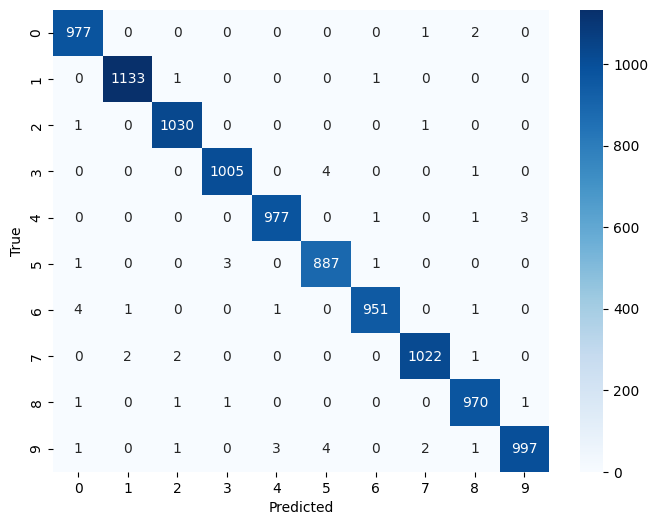

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, ensemble_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

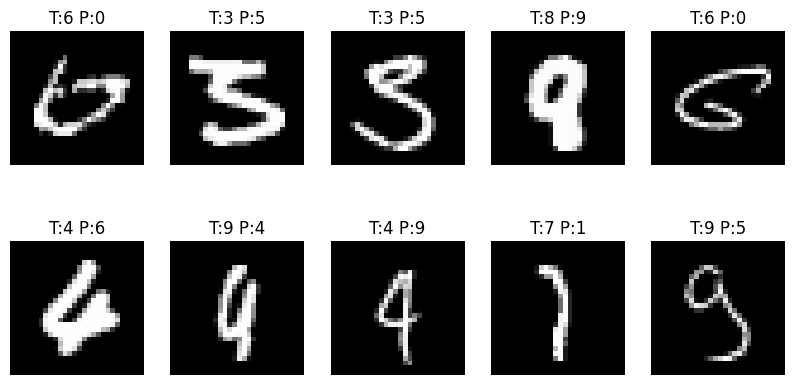

In [ ]:
mis_idx = np.where(ensemble_preds != y_true)[0]
plt.figure(figsize=(10, 5))
for i, idx in enumerate(mis_idx[:10]):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"T:{y_true[idx]} P:{ensemble_preds[idx]}")
    plt.axis('off')
plt.show()

## Saving the Model

In [ ]:
cnn_model.save("cnn_model.h5")
resnet_model.save("resnet_model.h5")
capsule_model.save("capsule_model.h5")